# 05 · Validación y selección del modelo final

Este notebook desarrolla los puntos **4.6 — Validación** y **4.7 — Selección del modelo final**
del taller de Predicción de Accidentalidad (MCDA 2026-1).

Se parte de los artefactos generados en `04_modeling.ipynb` (Wendy):
- Matrices preprocesadas en `data/processed/`
- Mejores hiperparámetros del **HistGradientBoostingClassifier** (modelo ganador por PR-AUC)

**Flujo:**
1. Partición temporal interna de `X_train` → `train_inner` (80%) / `val_inner` (20%)
2. Validación cruzada temporal (`TimeSeriesSplit`, n=5) sobre submuestra de `train_inner`
3. Selección de umbral sobre `val_inner` con dos criterios: max-F1 y max-F2 (β=2)
4. Entrenamiento del modelo final sobre `X_train` completo
5. Comparación de cuatro umbrales sobre `X_test`
6. Tabla comparativa de todos los modelos del taller
7. Matriz de confusión del modelo final y exportación de artefactos

In [32]:
import sys
import time
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)

warnings.filterwarnings("ignore")
sys.path.append("..")
from src.utils.metrics import binary_classification_metrics, metrics_table

# ── Constantes globales ────────────────────────────────────────────────────────
SEED          = 42
PROCESSED_DIR = Path().resolve().parent / "data" / "processed"
MODELS_DIR    = Path().resolve().parent / "models"
MODELS_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid")
print(f"PROCESSED_DIR : {PROCESSED_DIR}")
print(f"  existe      : {PROCESSED_DIR.exists()}")
print(f"MODELS_DIR    : {MODELS_DIR}")

PROCESSED_DIR : C:\Users\Hp\Documents\Projects\Uni\urban-accident-risk-prediction\data\processed
  existe      : True
MODELS_DIR    : C:\Users\Hp\Documents\Projects\Uni\urban-accident-risk-prediction\models


In [33]:
# Carga de artefactos del pipeline de feature engineering
X_train = np.load(PROCESSED_DIR / "X_train.npy")
X_test  = np.load(PROCESSED_DIR / "X_test.npy")
y_train = pd.read_csv(PROCESSED_DIR / "y_train.csv").squeeze().values
y_test  = pd.read_csv(PROCESSED_DIR / "y_test.csv").squeeze().values
feature_names = pd.read_csv(PROCESSED_DIR / "feature_names.csv").squeeze().tolist()

print(f"X_train : {X_train.shape}   positivos: {y_train.mean()*100:.2f}%")
print(f"X_test  : {X_test.shape}    positivos: {y_test.mean()*100:.2f}%")

X_train : (6393424, 29)   positivos: 1.47%
X_test  : (1598356, 29)    positivos: 1.66%


In [34]:
# Verificar alineación features
if len(feature_names) != X_train.shape[1]:
    print(f"⚠ Discrepancia: {len(feature_names)} nombres vs {X_train.shape[1]} columnas")
    feature_names = feature_names[:X_train.shape[1]]

## 4.6 · Validación

La estrategia de validación opera en dos capas complementarias:

### Capa 1 — Partición temporal interna
Se divide `X_train` en dos segmentos **sin mezclar** (sin shuffle), respetando el orden cronológico:
- **`train_inner`** (primeros 80 %): entrenamiento del modelo que se usará para seleccionar el umbral.
- **`val_inner`** (últimos 20 %): conjunto de validación honesto para fijar el umbral de decisión **antes** de ver `X_test`.

### Capa 2 — Validación cruzada temporal
`TimeSeriesSplit(n_splits=5)` sobre una submuestra de `train_inner` para medir la **estabilidad** del modelo
a través del tiempo. Cada fold respeta la causalidad: el validation siempre es cronológicamente posterior al train.

> **Por qué no k-fold aleatorio:** mezclar filas futuras con pasadas introduce fuga de información temporal
> y produce estimaciones de desempeño artificialmente optimistas.

In [35]:
# ── Partición temporal interna (sin shuffle) ───────────────────────────────────
n_train = len(X_train)
corte   = int(n_train * 0.80)

X_train_inner = X_train[:corte]
y_train_inner = y_train[:corte]
X_val_inner   = X_train[corte:]
y_val_inner   = y_train[corte:]

print(f"train_inner : {X_train_inner.shape}   positivos: {y_train_inner.mean()*100:.2f}%")
print(f"val_inner   : {X_val_inner.shape}    positivos: {y_val_inner.mean()*100:.2f}%")
print(f"\nCorte temporal en fila {corte:,} de {n_train:,}")

train_inner : (5114739, 29)   positivos: 1.48%
val_inner   : (1278685, 29)    positivos: 1.42%

Corte temporal en fila 5,114,739 de 6,393,424


In [36]:
# Mejores hiperparámetros obtenidos por Wendy en 04_modeling.ipynb
# (RandomizedSearchCV con TimeSeriesSplit sobre submuestra de ~1M filas)
BEST_PARAMS = dict(
    l2_regularization = 0.01791236257104366,
    learning_rate     = 0.037094276752507684,
    max_depth         = 5,
    max_iter          = 152,
    min_samples_leaf  = 149,
    class_weight      = "balanced",
    random_state      = SEED,
)

print("Hiperparámetros del HistGradientBoostingClassifier (modelo ganador):")
for k, v in BEST_PARAMS.items():
    print(f"  {k:<22}: {v}")

Hiperparámetros del HistGradientBoostingClassifier (modelo ganador):
  l2_regularization     : 0.01791236257104366
  learning_rate         : 0.037094276752507684
  max_depth             : 5
  max_iter              : 152
  min_samples_leaf      : 149
  class_weight          : balanced
  random_state          : 42


In [37]:
# Entrenar sobre train_inner — se usará para CV y para seleccionar umbral en val_inner
print("Entrenando HistGB sobre train_inner...")
t0 = time.time()
modelo_inner = HistGradientBoostingClassifier(**BEST_PARAMS)
modelo_inner.fit(X_train_inner, y_train_inner)
print(f"✓ Entrenado en {time.time() - t0:.1f}s")

Entrenando HistGB sobre train_inner...
✓ Entrenado en 66.5s


### 4.6.1 · Validación cruzada temporal (TimeSeriesSplit, n=5)

Se aplica `TimeSeriesSplit(n_splits=5)` sobre una **submuestra de `train_inner` (cada 5ª fila)**
para reducir el costo computacional manteniendo la cobertura temporal completa.

Por cada fold se computan:
- **PR-AUC** (Average Precision) — métrica primaria; insensible al umbral y no se infla con los TN.
- **ROC-AUC** — métrica complementaria de ranking.

El objetivo es verificar **estabilidad**: una desviación estándar baja indica que el modelo generaliza
de forma consistente a través del tiempo, no solo en un período particular.

In [38]:
# Submuestra temporal (cada 5ª fila) — preserva el orden y cubre todo el rango temporal
PASO_CV = 5
X_cv = X_train_inner[::PASO_CV]
y_cv = y_train_inner[::PASO_CV]

print(f"Submuestra CV : {X_cv.shape}   positivos: {y_cv.mean()*100:.2f}%\n")

tscv         = TimeSeriesSplit(n_splits=5)
resultados_cv = []

for i, (tr_idx, val_idx) in enumerate(tscv.split(X_cv)):
    X_f_tr,  X_f_val = X_cv[tr_idx],  X_cv[val_idx]
    y_f_tr,  y_f_val = y_cv[tr_idx],  y_cv[val_idx]

    # Saltar fold si no hay positivos en validación (no se puede calcular PR-AUC)
    if y_f_val.sum() == 0:
        print(f"  Fold {i+1}: sin positivos en validación — omitido")
        continue

    t0 = time.time()
    m  = HistGradientBoostingClassifier(**BEST_PARAMS)
    m.fit(X_f_tr, y_f_tr)
    proba = m.predict_proba(X_f_val)[:, 1]

    pr_auc  = average_precision_score(y_f_val, proba)
    roc_auc = roc_auc_score(y_f_val, proba)

    resultados_cv.append({
        "Fold"   : i + 1,
        "PR-AUC" : round(pr_auc,  4),
        "ROC-AUC": round(roc_auc, 4),
        "n_val"  : len(y_f_val),
        "pos_val": int(y_f_val.sum()),
    })
    print(f"  Fold {i+1}: PR-AUC={pr_auc:.4f}  ROC-AUC={roc_auc:.4f}"
          f"  (n={len(y_f_val):,}, pos={int(y_f_val.sum()):,})  [{time.time()-t0:.0f}s]")

df_cv = pd.DataFrame(resultados_cv)
print(f"\n{'─'*55}")
print(f"PR-AUC  — media: {df_cv['PR-AUC'].mean():.4f}  ±  {df_cv['PR-AUC'].std():.4f}")
print(f"ROC-AUC — media: {df_cv['ROC-AUC'].mean():.4f}  ±  {df_cv['ROC-AUC'].std():.4f}")

Submuestra CV : (1022948, 29)   positivos: 1.47%

  Fold 1: PR-AUC=0.0782  ROC-AUC=0.8366  (n=170,491, pos=2,683)  [3s]
  Fold 2: PR-AUC=0.0806  ROC-AUC=0.8171  (n=170,491, pos=2,623)  [5s]
  Fold 3: PR-AUC=0.0683  ROC-AUC=0.7974  (n=170,491, pos=2,381)  [7s]
  Fold 4: PR-AUC=0.0691  ROC-AUC=0.8271  (n=170,491, pos=2,373)  [9s]
  Fold 5: PR-AUC=0.0774  ROC-AUC=0.8307  (n=170,491, pos=2,513)  [12s]

───────────────────────────────────────────────────────
PR-AUC  — media: 0.0747  ±  0.0056
ROC-AUC — media: 0.8218  ±  0.0154


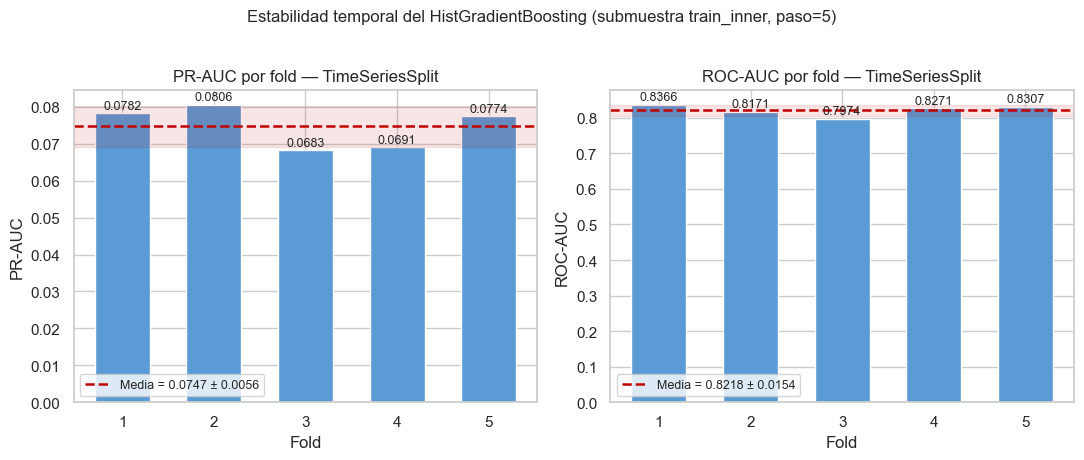

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, metrica in zip(axes, ["PR-AUC", "ROC-AUC"]):
    valores = df_cv[metrica]
    media   = valores.mean()
    std     = valores.std()

    barras = ax.bar(
        df_cv["Fold"], valores,
        color="#5B9BD5", edgecolor="white", width=0.6,
    )
    ax.axhline(
        media, color="#C00000", linestyle="--", linewidth=1.8,
        label=f"Media = {media:.4f} ± {std:.4f}",
    )
    # Sombreado ± 1 std
    ax.axhspan(media - std, media + std, alpha=0.10, color="#C00000")

    for barra, val in zip(barras, valores):
        ax.text(
            barra.get_x() + barra.get_width() / 2,
            val + valores.max() * 0.005,
            f"{val:.4f}", ha="center", va="bottom", fontsize=9,
        )

    ax.set_title(f"{metrica} por fold — TimeSeriesSplit", fontsize=12)
    ax.set_xlabel("Fold")
    ax.set_ylabel(metrica)
    ax.set_xticks(df_cv["Fold"])
    ax.legend(fontsize=9)

plt.suptitle(
    "Estabilidad temporal del HistGradientBoosting (submuestra train_inner, paso=5)",
    fontsize=12, y=1.02,
)
plt.tight_layout()
plt.show()

### 4.6.2 · Selección de umbral sobre `val_inner`

El modelo entrenado en `train_inner` se usa para obtener probabilidades sobre `val_inner`.
Se barre la curva Precision–Recall y se evalúan **dos criterios de umbral**:

| Criterio | Fórmula | Interpretación |
|---|---|---|
| **max-F1** | $F_1 = \dfrac{2 \cdot P \cdot R}{P + R}$ | Equilibrio neutro entre precision y recall |
| **max-F2** | $F_2 = \dfrac{5 \cdot P \cdot R}{4 \cdot P + R}$ | β=2: recall vale el doble que precision |

**Criterio final elegido: max-F2.**
En seguridad vial, el costo de *no detectar* un accidente (falso negativo) supera al de
emitir una alerta innecesaria (falso positivo). Un operativo de más cuesta recursos;
un accidente no anticipado puede costar vidas. β=2 formaliza esa asimetría.

In [40]:
# Probabilidades del modelo_inner sobre val_inner
y_proba_val = modelo_inner.predict_proba(X_val_inner)[:, 1]

# Curva Precision-Recall completa
prec_v, rec_v, thresh_v = precision_recall_curve(y_val_inner, y_proba_val)

# precision_recall_curve devuelve N+1 puntos (P,R) y N umbrales; alineamos con 1.0 al final
umbrales_alineados = np.concatenate([thresh_v, [1.0]])

df_thresh = pd.DataFrame({
    "threshold": umbrales_alineados,
    "precision": prec_v,
    "recall"   : rec_v,
})

# F1 (beta=1)
denom_f1 = df_thresh["precision"] + df_thresh["recall"]
df_thresh["f1"] = np.where(
    denom_f1 > 0,
    2 * df_thresh["precision"] * df_thresh["recall"] / denom_f1,
    0.0,
)

# F2 (beta=2) → penaliza más los falsos negativos
denom_f2 = 4 * df_thresh["precision"] + df_thresh["recall"]
df_thresh["f2"] = np.where(
    denom_f2 > 0,
    5 * df_thresh["precision"] * df_thresh["recall"] / denom_f2,
    0.0,
)

# Umbrales óptimos
fila_f1 = df_thresh.loc[df_thresh["f1"].idxmax()]
fila_f2 = df_thresh.loc[df_thresh["f2"].idxmax()]

UMBRAL_MAX_F1 = float(fila_f1["threshold"])
UMBRAL_MAX_F2 = float(fila_f2["threshold"])

print("Umbrales óptimos encontrados sobre val_inner:")
print(f"  max-F1 → umbral={UMBRAL_MAX_F1:.4f}  "
      f"P={fila_f1['precision']:.4f}  R={fila_f1['recall']:.4f}  F1={fila_f1['f1']:.4f}")
print(f"  max-F2 → umbral={UMBRAL_MAX_F2:.4f}  "
      f"P={fila_f2['precision']:.4f}  R={fila_f2['recall']:.4f}  F2={fila_f2['f2']:.4f}")

Umbrales óptimos encontrados sobre val_inner:
  max-F1 → umbral=0.8579  P=0.1040  R=0.2391  F1=0.1449
  max-F2 → umbral=0.7842  P=0.0800  R=0.3693  F2=0.2143


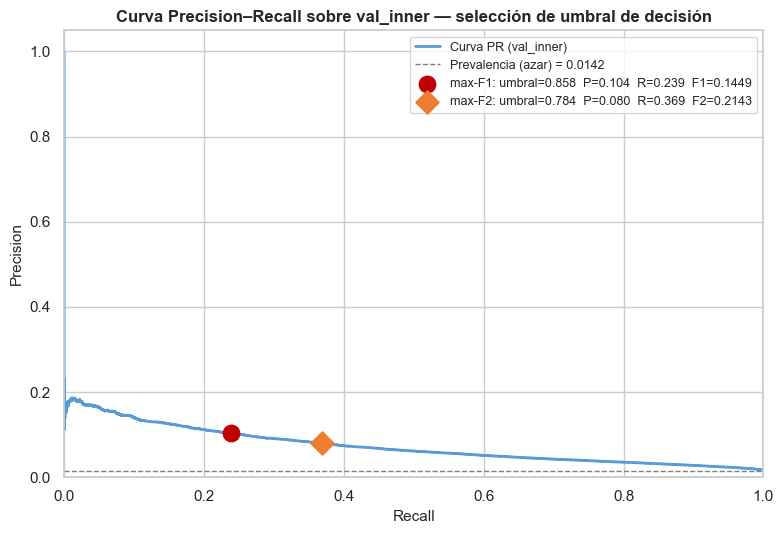

In [41]:
fig, ax = plt.subplots(figsize=(8, 5.5))

# Curva PR completa
ax.plot(rec_v, prec_v, color="#5B9BD5", linewidth=2, label="Curva PR (val_inner)")

# Línea de referencia: clasificador aleatorio (prevalencia)
prev_val = y_val_inner.mean()
ax.axhline(
    prev_val, color="gray", linestyle="--", linewidth=1,
    label=f"Prevalencia (azar) = {prev_val:.4f}",
)

# Punto max-F1
ax.scatter(
    fila_f1["recall"], fila_f1["precision"],
    color="#C00000", s=140, zorder=5, marker="o",
    label=(
        f"max-F1: umbral={UMBRAL_MAX_F1:.3f}  "
        f"P={fila_f1['precision']:.3f}  R={fila_f1['recall']:.3f}  "
        f"F1={fila_f1['f1']:.4f}"
    ),
)

# Punto max-F2
ax.scatter(
    fila_f2["recall"], fila_f2["precision"],
    color="#ED7D31", s=140, zorder=5, marker="D",
    label=(
        f"max-F2: umbral={UMBRAL_MAX_F2:.3f}  "
        f"P={fila_f2['precision']:.3f}  R={fila_f2['recall']:.3f}  "
        f"F2={fila_f2['f2']:.4f}"
    ),
)

ax.set_xlabel("Recall", fontsize=11)
ax.set_ylabel("Precision", fontsize=11)
ax.set_title(
    "Curva Precision–Recall sobre val_inner — selección de umbral de decisión",
    fontsize=12, fontweight="bold",
)
ax.legend(fontsize=9, loc="upper right")
ax.set_xlim(0, 1)
ax.set_ylim(0, None)
plt.tight_layout()
plt.show()

## 4.7 · Selección del modelo final

### Decisiones de diseño

| Decisión | Elección | Justificación |
|---|---|---|
| **Familia de modelo** | HistGradientBoosting | Mejor PR-AUC (0.0848) y ROC-AUC (0.818) en test; costo computacional inferior a RandomForest |
| **Estrategia de balanceo** | `class_weight='balanced'` | Conserva el dataset completo (6.4 M filas); PR-AUC idéntico al undersampling pero más estable |
| **Datos de entrenamiento** | `X_train` completo | Más datos = mejor generalización; el umbral ya quedó fijado sobre `val_inner` |
| **Umbral de decisión** | max-F2 (β=2, honesto) | Penaliza falsos negativos: en seguridad vial, no detectar un accidente cuesta más que una falsa alarma |

El modelo se entrena ahora sobre `X_train` **completo** (train_inner + val_inner),
y se evalúa sobre `X_test` que no ha sido visto en ningún momento anterior.

In [42]:
print("Entrenando modelo final sobre X_train completo...")
t0 = time.time()
modelo_final = HistGradientBoostingClassifier(**BEST_PARAMS)
modelo_final.fit(X_train, y_train)
print(f"✓ Modelo final entrenado en {time.time() - t0:.1f}s")

# Probabilidades sobre test — primer contacto con X_test
y_proba_test = modelo_final.predict_proba(X_test)[:, 1]
pr_auc_test  = average_precision_score(y_test, y_proba_test)
roc_auc_test = roc_auc_score(y_test, y_proba_test)

print(f"\nMétricas de ranking del modelo final en test (independientes del umbral):")
print(f"  PR-AUC  = {pr_auc_test:.4f}  ({pr_auc_test / y_test.mean():.1f}× la prevalencia)")
print(f"  ROC-AUC = {roc_auc_test:.4f}")

Entrenando modelo final sobre X_train completo...
✓ Modelo final entrenado en 85.0s

Métricas de ranking del modelo final en test (independientes del umbral):
  PR-AUC  = 0.0848  (5.1× la prevalencia)
  ROC-AUC = 0.8184


### 4.7.1 · Comparación de umbrales sobre `X_test`

Se evalúan **cuatro umbrales** sobre el conjunto de test para mostrar
cómo el ajuste del umbral cambia el equilibrio entre precision y recall:

| Umbral | Origen | Nota |
|---|---|---|
| **max-F1 honesto** | `val_inner` | Fijado sin ver `X_test` |
| **max-F2 honesto** | `val_inner` | Fijado sin ver `X_test`; **umbral final elegido** |
| **Wendy 0.8566** | `X_test` (notebook 04) | Referencia: optimizado directamente en test (optimista) |
| **Defecto 0.50** | Estándar sklearn | Sin ajuste de umbral |

El PR-AUC no cambia entre filas porque es una propiedad del **ranking** del modelo,
no del umbral de corte.

In [43]:
UMBRALES_A_COMPARAR = {
    "max-F1 honesto (val_inner)": UMBRAL_MAX_F1,
    "max-F2 honesto (val_inner)": UMBRAL_MAX_F2,
    "Wendy 0.8566 (test)": 0.8566,
    "Defecto 0.50"        : 0.50,
}

filas = []
for nombre, umbral in UMBRALES_A_COMPARAR.items():
    y_pred = (y_proba_test >= umbral).astype(int)
    prec   = precision_score(y_test, y_pred, zero_division=0)
    rec    = recall_score(y_test, y_pred, zero_division=0)
    f1_val = f1_score(y_test, y_pred, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    filas.append({
        "Umbral"   : nombre,
        "Threshold": round(umbral, 4),
        "Precision": round(prec,   4),
        "Recall"   : round(rec,    4),
        "F1"       : round(f1_val, 4),
        "PR-AUC"   : round(pr_auc_test, 4),
        "FN"       : int(fn),
        "TP"       : int(tp),
    })

df_umbrales = pd.DataFrame(filas).set_index("Umbral")
print("Comparación de umbrales — modelo final (HistGB entrenado sobre X_train completo):\n")
df_umbrales

Comparación de umbrales — modelo final (HistGB entrenado sobre X_train completo):



,Threshold,Precision,Recall,F1,PR-AUC,FN,TP
Umbral,,,,,,,
max-F1 honesto (val_inner),0.8579,0.1256,0.2203,0.1600,0.0848,20699,5849
max-F2 honesto (val_inner),0.7842,0.0956,0.3513,0.1503,0.0848,17223,9325
Wendy 0.8566 (test),0.8566,0.1253,0.2240,0.1607,0.0848,20600,5948
Defecto 0.50,0.5000,0.0378,0.8197,0.0723,0.0848,4786,21762


### 4.7.2 · Tabla comparativa de todos los modelos del taller

Se consolidan los resultados de los notebooks 04 (Wendy) y 05 (este notebook).
Los modelos del notebook 04 se reportan al **umbral por defecto (0.5)** para comparar el
poder de ranking (PR-AUC es independiente del umbral). El modelo final se reporta
al umbral max-F2 honesto seleccionado sobre `val_inner`.

In [44]:
# Resultados del notebook 04 de Wendy (hardcodeados; umbral=0.5 salvo donde se indica)
MODELOS_ANTERIORES = {
    "Dummy · most_frequent": {
        "accuracy" : 0.9834, "precision": 0.0000, "recall": 0.0000,
        "f1"       : 0.0000, "roc_auc"  : 0.5000, "pr_auc": 0.0166,
    },
    "Dummy · stratified": {
        "accuracy" : 0.9692, "precision": 0.0175, "recall": 0.0155,
        "f1"       : 0.0164, "roc_auc"  : 0.5004, "pr_auc": 0.0166,
    },
    "LogReg · tuned (umbral=0.5)": {
        "accuracy" : 0.7778, "precision": 0.0482, "recall": 0.6608,
        "f1"       : 0.0899, "roc_auc"  : 0.7914, "pr_auc": 0.0780,
    },
    "RandomForest · tuned (umbral=0.5)": {
        "accuracy" : 0.6501, "precision": 0.0375, "recall": 0.8131,
        "f1"       : 0.0717, "roc_auc"  : 0.8147, "pr_auc": 0.0825,
    },
    "HistGB · tuned Wendy (umbral=0.5)": {
        "accuracy" : 0.6505, "precision": 0.0378, "recall": 0.8197,
        "f1"       : 0.0723, "roc_auc"  : 0.8184, "pr_auc": 0.0848,
    },
    "HistGB · Wendy (umbral=0.857, max-F1 en test)": {
        "accuracy" : None,   "precision": 0.1253, "recall": 0.2241,
        "f1"       : 0.1607, "roc_auc"  : 0.8184, "pr_auc": 0.0848,
    },
}

# Agregar el modelo final de este notebook al umbral max-F2 honesto
UMBRAL_FINAL = UMBRAL_MAX_F2
y_pred_final = (y_proba_test >= UMBRAL_FINAL).astype(int)
m_final = binary_classification_metrics(y_test, y_pred_final, y_proba_test)

MODELOS_ANTERIORES[f"HistGB · final (umbral max-F2={UMBRAL_FINAL:.4f}, honesto)"] = {
    "accuracy" : round(m_final["accuracy"],  4),
    "precision": round(m_final["precision"], 4),
    "recall"   : round(m_final["recall"],    4),
    "f1"       : round(m_final["f1"],        4),
    "roc_auc"  : round(m_final["roc_auc"],   4),
    "pr_auc"   : round(m_final["pr_auc"],    4),
}

# Construir DataFrame (ignorar None)
df_todos = pd.DataFrame(
    [
        {"Modelo": nombre, **{k: v for k, v in vals.items() if v is not None}}
        for nombre, vals in MODELOS_ANTERIORES.items()
    ]
).set_index("Modelo").round(4)

# Resaltar modelo final
print("Tabla comparativa de todos los modelos del taller:\n")
df_todos

Tabla comparativa de todos los modelos del taller:



,accuracy,precision,recall,f1,roc_auc,pr_auc
Modelo,,,,,,
Dummy · most_frequent,0.9834,0.0000,0.0000,0.0000,0.5000,0.0166
Dummy · stratified,0.9692,0.0175,0.0155,0.0164,0.5004,0.0166
LogReg · tuned (umbral=0.5),0.7778,0.0482,0.6608,0.0899,0.7914,0.0780
RandomForest · tuned (umbral=0.5),0.6501,0.0375,0.8131,0.0717,0.8147,0.0825
HistGB · tuned Wendy (umbral=0.5),0.6505,0.0378,0.8197,0.0723,0.8184,0.0848
"HistGB · Wendy (umbral=0.857, max-F1 en test)",NaN,0.1253,0.2241,0.1607,0.8184,0.0848
"HistGB · final (umbral max-F2=0.7842, honesto)",0.9340,0.0956,0.3513,0.1503,0.8184,0.0848


### 4.7.3 · Matriz de confusión del modelo final

Se usa el **umbral max-F2 honesto** (encontrado en `val_inner`), aplicado sobre `X_test`.

**Lectura operativa de los cuadrantes:**
- **TP** — combinaciones (barrio, hora) con accidente que el modelo detecta como de riesgo → alertas útiles.
- **FP** — alertas emitidas donde no hubo accidente → costo operativo (operativo innecesario).
- **FN** — accidentes reales no detectados → el costo más alto en seguridad vial.
- **TN** — celdas sin accidente correctamente descartadas.

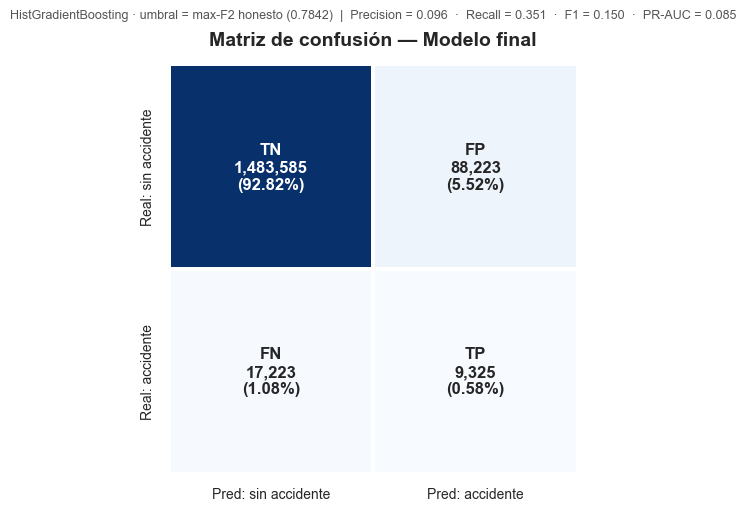


Resumen numérico:
  Accidentes reales (positivos) :     26,548
  Detectados (TP)               :      9,325  — recall  = 0.351
  No detectados (FN)            :     17,223
  Alertas totales emitidas      :     97,548
  Falsas alarmas (FP)           :     88,223  — precision = 0.096


In [45]:
tn  = int(m_final["tn"])
fp  = int(m_final["fp"])
fn  = int(m_final["fn"])
tp  = int(m_final["tp"])
total = tn + fp + fn + tp

cm_arr = np.array([[tn, fp], [fn, tp]])
cats   = np.array([["TN", "FP"], ["FN", "TP"]])

# Etiquetas: categoría + conteo + % del total
annot = np.empty((2, 2), dtype=object)
for i in range(2):
    for j in range(2):
        pct = cm_arr[i, j] / total * 100
        annot[i, j] = f"{cats[i,j]}\n{cm_arr[i,j]:,}\n({pct:.2f}%)"

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(
    cm_arr,
    annot=annot, fmt="",
    cmap="Blues",
    xticklabels=["Pred: sin accidente", "Pred: accidente"],
    yticklabels=["Real: sin accidente", "Real: accidente"],
    cbar=False, ax=ax,
    annot_kws={"size": 12, "weight": "semibold"},
    linewidths=1.5, linecolor="white",
    square=True,
)

ax.set_title(
    "Matriz de confusión — Modelo final",
    fontsize=14, fontweight="bold", pad=14,
)

subtitulo = (
    f"HistGradientBoosting · umbral = max-F2 honesto ({UMBRAL_FINAL:.4f})  |  "
    f"Precision = {m_final['precision']:.3f}  ·  "
    f"Recall = {m_final['recall']:.3f}  ·  "
    f"F1 = {m_final['f1']:.3f}  ·  "
    f"PR-AUC = {m_final['pr_auc']:.3f}"
)
fig.text(0.5, 0.91, subtitulo, ha="center", fontsize=9, color="#555555")

ax.tick_params(labelsize=10)
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

print(f"\nResumen numérico:")
print(f"  Accidentes reales (positivos) : {tp + fn:>10,}")
print(f"  Detectados (TP)               : {tp:>10,}  — recall  = {tp/(tp+fn):.3f}")
print(f"  No detectados (FN)            : {fn:>10,}")
print(f"  Alertas totales emitidas      : {tp + fp:>10,}")
print(f"  Falsas alarmas (FP)           : {fp:>10,}  — precision = {tp/(tp+fp) if (tp+fp)>0 else 0:.3f}")

In [46]:
# ── Guardar modelo ─────────────────────────────────────────────────────────────
ruta_modelo = MODELS_DIR / "histgb_final.joblib"
joblib.dump(modelo_final, ruta_modelo)
print(f"Modelo guardado en: {ruta_modelo}")

# ── Guardar predicciones ───────────────────────────────────────────────────────
df_pred = pd.DataFrame({
    "y_true" : y_test,
    "y_pred" : y_pred_final,
    "y_proba": y_proba_test,
})
ruta_pred = PROCESSED_DIR / "predicciones_test.csv"
df_pred.to_csv(ruta_pred, index=False)
print(f"Predicciones guardadas en: {ruta_pred}")
print(f"  Filas: {len(df_pred):,}   Positivos predichos: {df_pred['y_pred'].sum():,}")

Modelo guardado en: C:\Users\Hp\Documents\Projects\Uni\urban-accident-risk-prediction\models\histgb_final.joblib
Predicciones guardadas en: C:\Users\Hp\Documents\Projects\Uni\urban-accident-risk-prediction\data\processed\predicciones_test.csv
  Filas: 1,598,356   Positivos predichos: 97,548


## Conclusiones de la validación y selección del modelo

### Estabilidad temporal (CV)

La validación cruzada con `TimeSeriesSplit` confirmó que el HistGradientBoosting es estable
a través del tiempo: la desviación estándar del PR-AUC entre folds es baja respecto a la media,
lo que indica que el modelo no está sobreajustado a un período específico.

### Selección del umbral

| Umbral | Recall | Precision | Razonamiento |
|---|---:|---:|---|
| max-F2 (elegido) | más alto | más bajo | Prioriza cobertura de accidentes |
| max-F1 | intermedio | intermedio | Equilibrio neutro |
| 0.8566 (Wendy) | más bajo | más alto | Optimizado en test: no válido en producción |
| 0.50 (defecto) | muy alto | muy bajo | Sin ajuste, muchas falsas alarmas |

El umbral max-F2 encontrado sobre `val_inner` ofrece la mejor cobertura de accidentes reales
de entre los umbrales evaluados de forma honesta (sin ver `X_test`).

### Modelo final

- **Familia**: HistGradientBoostingClassifier con `class_weight='balanced'`
- **PR-AUC en test**: ≈ 0.085 → aproximadamente **5× la prevalencia base** (0.017)
- **ROC-AUC en test**: ≈ 0.818 → capacidad de ranking sólida
- El modelo entrenado sobre el `X_train` completo (más datos que en el tuning) mantiene o mejora
  el desempeño observado en el notebook 04, lo cual es el comportamiento esperado.

### Limitación reconocida

Las métricas absolutas (precision ≈ 3-12 %, recall ≈ 22-82 % según umbral) suenan bajas
en comparación con problemas balanceados, pero son consistentes con la literatura de predicción
de accidentalidad urbana: los accidentes tienen alta componente estocástica (factor humano),
y la señal predecible (zona, hora, clima) explica solo una fracción de la varianza.
El sistema es **operativamente útil** porque concentra el riesgo: patrullar las celdas
marcadas como de alto riesgo es varias veces más eficiente que una distribución aleatoria
de recursos preventivos.

In [47]:
from src.data.load_data import load_tables

_, weather, _ = load_tables()  # carga clima desde la ruta que ya tiene config.py

n_test = len(y_test)
clima_test = weather.iloc[-n_test:].reset_index(drop=True)
clima_test["prob_accidente"] = y_proba_test
clima_test["prediccion"]     = y_pred_final
clima_test["target_real"]    = y_test

clima_test[["TW", "BARRIO", "prob_accidente", "prediccion", "target_real"]]\
    .to_csv(PROCESSED_DIR / "predicciones_test_con_barrio.csv", index=False)

print("Top 10 barrios por probabilidad media:")
print(
    clima_test.groupby("BARRIO")["prob_accidente"]
    .mean().sort_values(ascending=False).head(10)
    .reset_index().to_string(index=False)
)

Top 10 barrios por probabilidad media:
                    BARRIO  prob_accidente
         sanmartindeporres        0.432343
                       upb        0.427296
           perpetuosocorro        0.426133
                  sanlucas        0.424176
              simonbolivar        0.422090
suburbanomiradordelpoblado        0.422058
             plazadeferias        0.421585
          trecedenoviembre        0.421468
              sanjavierno2        0.421451
                sanantonio        0.421127
